The four adjacent digits in the 1000-digit number that have the greatest product are 9x9x8x9=5832.

Find the thirteen adjacent digits in the 1000-digit number that have the greatest product. What is the value of this product?

In [1]:
number ='''
73167176531330624919225119674426574742355349194934
96983520312774506326239578318016984801869478851843
85861560789112949495459501737958331952853208805511
12540698747158523863050715693290963295227443043557
66896648950445244523161731856403098711121722383113
62229893423380308135336276614282806444486645238749
30358907296290491560440772390713810515859307960866
70172427121883998797908792274921901699720888093776
65727333001053367881220235421809751254540594752243
52584907711670556013604839586446706324415722155397
53697817977846174064955149290862569321978468622482
83972241375657056057490261407972968652414535100474
82166370484403199890008895243450658541227588666881
16427171479924442928230863465674813919123162824586
17866458359124566529476545682848912883142607690042
24219022671055626321111109370544217506941658960408
07198403850962455444362981230987879927244284909188
84580156166097919133875499200524063689912560717606
05886116467109405077541002256983155200055935729725
71636269561882670428252483600823257530420752963450
'''.replace('\n', '')
n=1_000

# Primer intento:

primer intento basado en slicer de strings de python

In [2]:
import math
def primer_intento():
    n_int = 0
    for i in range(n - 12):
        n_int = max(n_int, math.prod(map(lambda x: int(x), number[i:13+i:])))
    return n_int

primer_intento()

23514624000

# Optimizacion:

chatgpt recomienda usar una ventana deslizante para actualizar el producto en cada paso y tratar los ceros aparte, pero trabajando directamente sobre el string para no reservar una lista adicional de digitos:

In [3]:
def optimizacion():
    ancho = 13
    resultado = 0
    producto = 1
    ceros = 0
    izquierda = 0

    for derecha, caracter in enumerate(number):
        digito = ord(caracter) - 48
        if digito == 0:
            ceros += 1
        else:
            producto *= digito

        if derecha - izquierda + 1 > ancho:
            saliente = ord(number[izquierda]) - 48
            if saliente == 0:
                ceros -= 1
            else:
                producto //= saliente
            izquierda += 1

        if derecha - izquierda + 1 == ancho and ceros == 0:
            if producto > resultado:
                resultado = producto

    return resultado

optimizacion()

23514624000

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 23514624000
Consistente: True
Repeticiones por corrida: 10
Tiempo promedio: 0.001112 s
Tiempo mediano: 0.001099 s
Tiempo minimo: 0.001089 s
Memoria promedio: 0.35 KB
Memoria mediana: 0.35 KB
Memoria maxima: 0.35 KB

--- Optimizacion ---
Resultado: 23514624000
Consistente: True
Repeticiones por corrida: 100
Tiempo promedio: 1.706712e-04 s
Tiempo mediano: 1.704429e-04 s
Tiempo minimo: 1.702602e-04 s
Memoria promedio: 0.37 KB
Memoria mediana: 0.37 KB
Memoria maxima: 0.37 KB


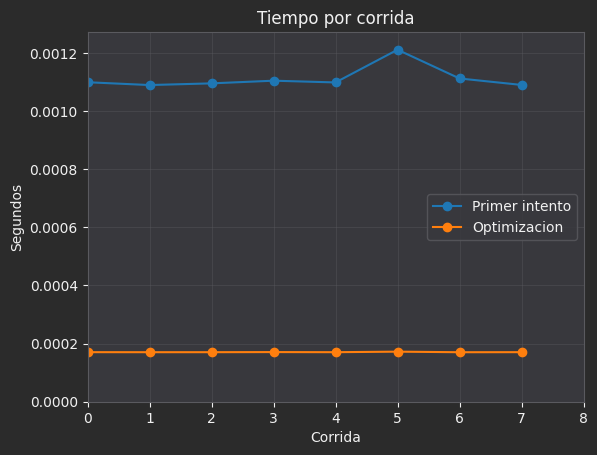

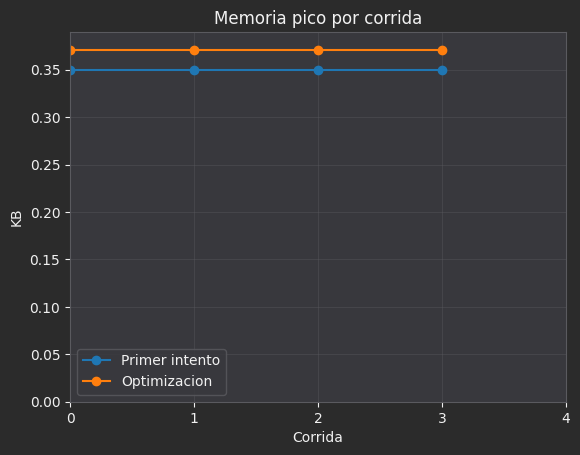

{'Primer intento': {'resultado': 23514624000,
  'consistente': True,
  'tiempos': [0.0010990494999999934,
   0.001089414600000005,
   0.0010951793000000044,
   0.0011044021999999875,
   0.0010983782999999913,
   0.001210922300000017,
   0.001112029400000014,
   0.0010898161000000074],
  'memorias': [0.349609375, 0.349609375, 0.349609375, 0.349609375],
  'repeticiones': 10},
 'Optimizacion': {'resultado': 23514624000,
  'consistente': True,
  'tiempos': [0.00017048330000000168,
   0.00017034723000000084,
   0.0001703910200000003,
   0.00017077739999999953,
   0.00017040242999999844,
   0.00017222456999999914,
   0.00017026021000000392,
   0.00017048374999999893],
  'memorias': [0.37109375, 0.37109375, 0.37109375, 0.37109375],
  'repeticiones': 100}}

In [4]:
from lib.utils import comparar_metodos

comparar_metodos(primer_intento, optimizacion)